In [130]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# PW 12

## Erklärung des ersten Experiments

In diesem Experiment wird das Verhalten eines Drehpendels, einmal ohne einer anregenden Kraft und einmal mit einer anregenden Kraft, beobachtet.
Im Fall einer freien Schwingung, folgt die Bewegung des Pendels folgender Differentialgleichung:
$$
ma + kv + Dx = 0
$$
wobei $k$ die Dämpfungs- oder Reibungskonstante mit SI-EInheit $\frac{kg}{s}$ ist und $D$ eine Systemabhängige Konstante. 
Im Fall einer erzwungenen Schwingung folgt die Bewegung des Pendels folgender Differentialgleichung:
$$
ma + kv + Dx = F_0 \cdot cos(\omega t)
$$

Unter Dämpfung erfährt die Schwingungsfrequenz $\omega_D$ des Pendels eine Abweichung von der Eigenfrequenz $\omega_0$, welcher der folgenden Gleichung folgt:
$$
\omega_D = \sqrt{\omega_0^2 - \delta^2}
$$
wobei $\delta$ den Dämpfungsskoeffizienten beschreibt, welcher mittels eines linearen Fits des Zusammenhangs
$$
\ln{\frac{x_i}{x_0}} = -\delta t_i
$$
als negative Steigung des Fits bestimmt werden kann.
Der Gütefaktor $Q$ wird wie folgt bestimmt:
$$
Q = \frac{\omega_0}{2\delta} 
$$

Die Schwingungskreisfrequenz beträgt 3.95+/-0.03 rad/s.
Die Dämpfungskonstante lässt sich aus der linearen Regression als 0.266+/-0.010 1/s bestimmen.


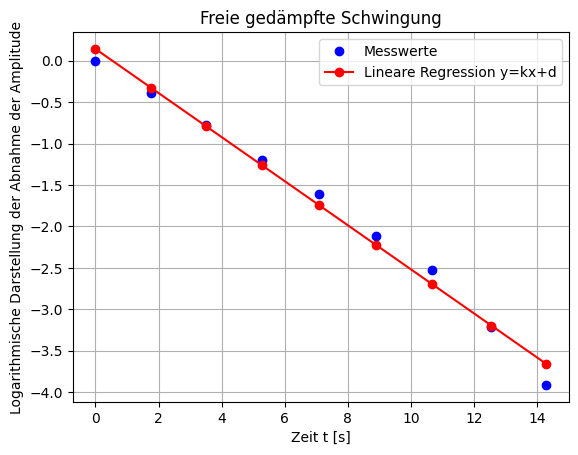

Die Eigenfrequenz beträgt 3.963+/-0.028 rad/s.


/tmp/ipykernel_5803/2307647880.py:66: FutureWarning: AffineScalarFunc.__lt__() is deprecated. It will be removed in a future release.
  omega_fit = np.linspace(min(omega_2), max(omega_2), 500)
/tmp/ipykernel_5803/2307647880.py:66: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  omega_fit = np.linspace(min(omega_2), max(omega_2), 500)


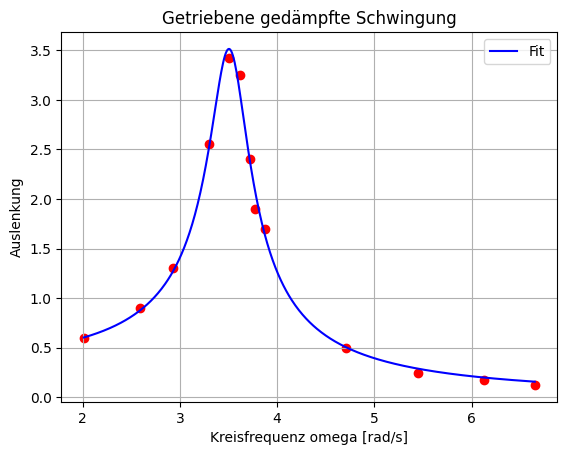

Der gemessene Dämpfungskoeffizient beträgt 0.2046+/-0.0093.
Der Gütefaktor der freien gedämpften Schwingung beträgt 7.46+/-0.30, für die erzwungene gedämpfte Schwingung wurde der Gütefaktor 8.73+/-0.06 berechnet. Zwischen ihnen liegt eine Differenz von -1.28+/-0.29.


In [131]:
# 1. Experiment

#t_int = np.array([2.83, 4.59, 6.35, 8.1, 9.93, 11.73, 13.49, 15.39, 17.13]-2.83) # start bei 2.83
t_int = np.array([0, 1.76, 3.52, 5.27, 7.1, 8.9, 10.66, 12.56, 14.3]) # start bei 0
#t_u = np.float(0.2) # in s
t = unp.uarray(t_int, 0.2) 
x_int = np.array([5, 3.4, 2.3, 1.5, 1, 0.6, 0.4, 0.2, 0.1])
#x_u = np.float(0.1) #in cm
x = unp.uarray(x_int, 0.1)
x0 = 5 # anfangsamplitude
b = ufloat(14.3, 0.1) # letzter gemessener zeitwert

T = b/len(t_int)
omega = (2*math.pi)/T 
print(f"Die Schwingungskreisfrequenz beträgt {omega:.2f} rad/s.")

y_1 = np.log(x_int/x0)
res1 = linregress(t_int, y_1)
delta_1 = ufloat(res1.slope, res1.stderr)*(-1) 
y_plot = res1.slope*t_int + res1.intercept
print(f"Die Dämpfungskonstante lässt sich aus der linearen Regression als {delta_1} 1/s bestimmen.")

plt.figure()
plt.plot(t_int, y_1, "o", label="Messwerte", color="blue") # sind nicht logarithmisch!! zuerst log dings machen
plt.plot(t_int, y_plot, "-o", label="Lineare Regression y=kx+d", color="red")
plt.xlabel("Zeit t [s]")
plt.ylabel("Logarithmische Darstellung der Abnahme der Amplitude")
plt.title("Freie gedämpfte Schwingung")
plt.grid(True)
plt.legend()
plt.show()

omega0 = unp.sqrt((omega)**2+(delta_1)**2)
omega0_int = unp.nominal_values(omega0)
print(f"Die Eigenfrequenz beträgt {omega0} rad/s.")

# 1.4
A_int = np.array([0.6, 0.9, 1.3, 2.55, 3.425, 3.25, 2.4, 1.9, 1.7, 0.5, 0.25, 0.175, 0.125])
A = unp.uarray(A_int, 0.1) # auslenkung
umdrehungen_int = np.array([192, 247, 280, 315, 335, 345, 355, 360, 370, 450, 520, 585, 635])
umdrehungen = unp.uarray(umdrehungen_int, 30)
#T_g = np.array([])/10
f = umdrehungen/(10*60)
f_int = umdrehungen_int/(10*60)
omega_2 = (2*math.pi)*f
omega_2_int = 2*math.pi*f_int


# modellfunktion

def modell(omega_2_int, omega0_int, delta,a):
    return a*(omega0_int**2)/np.sqrt((omega0_int**2 - omega_2_int**2)**2 + 4*(delta**2)*omega_2_int**2)

y_data = A_int

# fit durchführen
popt, pcov = curve_fit(modell, omega_2_int, y_data, p0=[3,1,1])

omega0_fit, delta_fit, a_fit = popt
#omega0_fit_int = unp.nominal_values(omega0_fit)
#delta_fit_int = unp.nominal_values(delta_fit)
omega0_fit_2 = ufloat(popt[0], np.sqrt(pcov[0,0]))
delta_fit_2 = ufloat(popt[1], np.sqrt(pcov[1,1]))


omega_fit = np.linspace(min(omega_2), max(omega_2), 500)
omega_fit_int = unp.nominal_values(omega_fit)
y_fit = modell(omega_2_int, omega0_fit, delta_fit, a_fit)
y_fit_2 = modell(omega_fit_int, omega0_fit, delta_fit, a_fit)


# chi2s = np.sum(((U_s_nom - y_fit)/u_U_s)**2) brauchen wir doch nicht und ist auch falsch
SS_res_s = np.sum((A - y_fit)**2)
SS_tot_s = np.sum((A - np.mean(y_data))**2)
R2_s = 1 - (SS_res_s / SS_tot_s) 

# plot

plt.scatter(omega_2_int, y_data, marker="o", color='red')
plt.plot(omega_fit_int, y_fit_2, label="Fit", color='blue')
plt.xlabel("Kreisfrequenz omega [rad/s]")
plt.ylabel("Auslenkung")
plt.title("Getriebene gedämpfte Schwingung")
plt.legend()
plt.grid(True)
plt.show()

# HALBWERTSBREITE DANN DELTA_2 
Amax = 3.425
imax = np.argmax(A)
Awurzel2 = (1/np.sqrt(2))*Amax
y1 = A_int[:imax+1]
omega1 = omega_2_int[:imax+1]
y2 = A_int[imax:]
omega2 = omega_2_int[imax:]
x1 = np.interp(Awurzel2, y1, omega1)
x2 = np.interp(Awurzel2, y2[::-1], omega2[::-1])
omegamax = 4980*2*math.pi #gemessen
deltax = x2 - x1
delta_2 = deltax/2 # abklären!!!

Q_1 = omega0/(2*delta_1)
Q_2 = omega0/(2*delta_2)
diff = Q_1 - Q_2

print(f"Der gemessene Dämpfungskoeffizient beträgt {delta_fit_2:.4f}.")
print(f"Der Gütefaktor der freien gedämpften Schwingung beträgt {Q_1}, für die erzwungene gedämpfte Schwingung wurde der Gütefaktor {Q_2} berechnet. Zwischen ihnen liegt eine Differenz von {diff}.")





## Erklärung des zweiten Experiments

Im zweiten Experiment werden gekoppelte Schwingungen betrachtet. Zwei Fadenpendel, mit der Kopplungslänge $l$ und der Pendellänge $L$, werden mit einer Aufhängung mit Kopplungsgewicht $G$ verbunden. In dem Kontext der gekoppelten Schwingungen gibt es die gleich- und gegensinnige Schwingung, sowie den Schwebungsfall, welcher hier näher beleuchtet wird. In diesem wird eines der beiden Pendel ausgelenkt, während das andere ruht. Die Energie des ausgelenkten Pendels überträgt sich dabei kontinuierlich auf das anfangs ruhende, welches dann ausgelenkt wird, dieser Prozess wiederholt sich. 
Dabei gibt es in dem System die beiden Eigenschwingungen $\omega_0$ und $\omega_1$, sowie die zu messende Schwebungsfrequenz $\omega_S$. All diese werden wie folgt ermittelt:
$$
\omega_0 = \omega_2 - \omega_S
$$
$$
\omega_1 = \omega_S + \omega_2
$$
$$
\omega_S = \frac{\pi}{T_S}
$$
wobei $\omega_S$ die zu messende Kreisfrequenz ist, mit welcher das Pendel schwingt.
Mit diesen Werten ist nun auch der Kopplungsgrad $K$ zu berechnen:
$$
K = \frac{2\omega_S\omega_2}{\omega_S^2 + \omega_2^2}



In [132]:
# 2. experiment

l = ufloat(41.4, 0.2) # in cm
L = ufloat(83.5 , 0.1)

T_s = ufloat(44, 0.5) # in s, zeit zwischen zwei stillständen desselben pendels
T_2 = ufloat(1.7, 0.5)
w_2 = (2*math.pi)/T_2
w_s = math.pi/T_s
w_0 = w_2 - w_s
w_1 = 2*w_2 - w_0

K = (2*w_s*w_2)/((w_s)**2+(w_2)**2)

print(f"Die Schwebungsfrequenz \u03c9_S = {w_s}, \u03c9_2 = {w_2}.")
print(f"Die Eigenfrequenzen der beiden Pendel betragen \u03c9_0 = {w_0} rad/s und \u03c9_1 = {w_1} rad/s.")
print(f"Der Kopplungsgrad K wurde als {K} bestimmt.")


Die Schwebungsfrequenz ω_S = 0.0714+/-0.0008, ω_2 = 3.7+/-1.1.
Die Eigenfrequenzen der beiden Pendel betragen ω_0 = 3.6+/-1.1 rad/s und ω_1 = 3.8+/-1.1 rad/s.
Der Kopplungsgrad K wurde als 0.039+/-0.011 bestimmt.


## Diskussion

Beim ersten Experiment kann die Messung nicht wirklich genau durchgeführt werden, da exakte Ablesung die menschlichen Fähigkeiten überschreitet. Dementsprechend wurde die Unsicherheit erhöht.
Weiters sind die Amplituden und damit auch die Gütefaktoren nicht so hoch, wie sie vielleicht mit weniger Dämpfung wären, da wir den Strom, der dann proportional zur Dämpfung wäre, als 400 mA gewählt haben.